### 시계열 데이터를 입수하여 시각화 하기

## iPhone Sales Dataset

**기간**: 2025년 1월 ~ 5월  
**크기**: 100건의 판매 기록

### 컬럼 설명

| 컬럼명 | 설명 |
|---|---|
| `Order_ID` | 주문 고유 번호 |
| `Customer_Name` | 고객명 |
| `Country` | 판매 국가 (USA, UK, Canada, Germany, UAE, Pakistan) |
| `iPhone_Model` | 판매 모델 (iPhone 12 ~ iPhone 15 Pro Max) |
| `Storage` | 저장 용량 (128GB / 256GB / 512GB) |
| `Color` | 색상 |
| `Quantity` | 판매 수량 |
| `Price` | 판매 단가 (USD) |
| `Sale_Date` | 판매 날짜 (YYYY-MM-DD) |
| `Payment_Method` | 결제 수단 (Credit Card / Debit Card / PayPal / Cash) |

### 시계열 분석 포인트

- `Sale_Date`를 기준으로 **월별/주별 매출 트렌드** 파악 가능
- 모델별, 국가별로 그룹화하여 **다차원 시계열 비교** 가능

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('datasets/iphone_sales_dataset.csv')

print("데이터 크기", df.shape)


데이터 크기 (100, 10)


Month
1    160408
2    103194
3    116740
4     99945
5     14166
Name: Revenue, dtype: int64


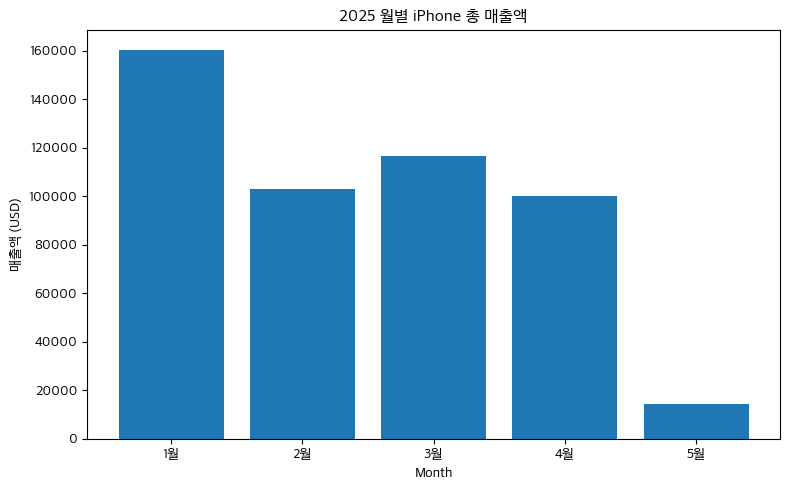

In [22]:
plt.rcParams["font.family"] = "Apple SD Gothic Neo"
plt.rcParams["axes.unicode_minus"] = False

df["Sale_Date"] = pd.to_datetime(df["Sale_Date"])
df["Month"] = df["Sale_Date"].dt.month
df["Revenue"] = df["Quantity"] * df["Price"]

# 월별 매출 합계
monthly_revenue = df.groupby("Month")["Revenue"].sum()
print(monthly_revenue)

# 시각화
plt.figure(figsize=(8, 5))
plt.bar(monthly_revenue.index, monthly_revenue.values)

plt.title("2025 월별 iPhone 총 매출액")
plt.xlabel("Month")
plt.ylabel("매출액 (USD)")
plt.xticks([1, 2, 3, 4, 5], ["1월", "2월", "3월", "4월", "5월"])

plt.tight_layout()
plt.show()

iPhone_Model  iPhone 12  iPhone 13  iPhone 14  iPhone 14 Pro  iPhone 15  \
Country                                                                   
Canada                1          8         14             20          1   
Germany               5         10          4              9          0   
Pakistan              0          9          5             12          7   
UAE                  11          6          3             10         15   
UK                    9          9          1              8         14   
USA                  16         17          9              7         20   

iPhone_Model  iPhone 15 Pro Max  
Country                          
Canada                       11  
Germany                       7  
Pakistan                      2  
UAE                           7  
UK                           38  
USA                           8  


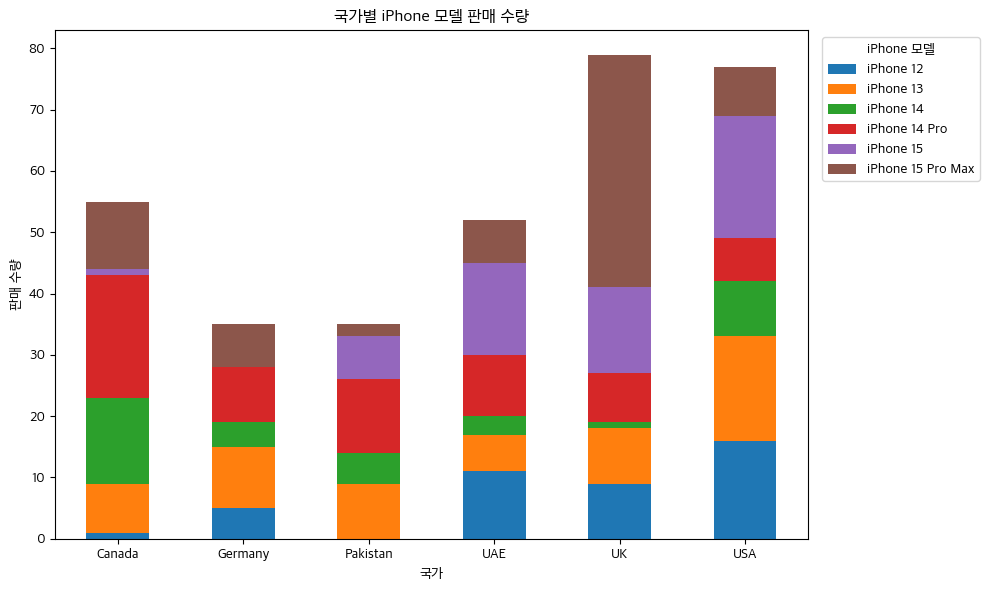

In [25]:
# 국가별 모델 판매 수량 집계
country_model = df.groupby(["Country", "iPhone_Model"])["Quantity"].sum().unstack(fill_value=0)
print(country_model)

# 누적 막대 그래프
country_model.plot(kind="bar", stacked=True, figsize=(10, 6))

plt.title("국가별 iPhone 모델 판매 수량")
plt.xlabel("국가")
plt.ylabel("판매 수량")
plt.xticks(rotation=0)
plt.legend(title="iPhone 모델", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()